In [6]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from mpl_toolkits.mplot3d import Axes3D
from scipy import stats

import subprocess

Slope: 0.00026
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


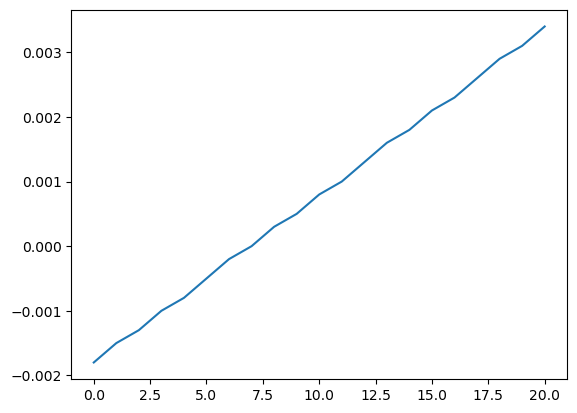

In [9]:
# trying to model array slice for sigma_t ~ 6 Jy 
rotated_array_slice = [
    0.,      -0.0018, -0.0015,
    -0.0013, -0.001,  -0.0008,
    -0.0005, -0.0002,  0.,
    0.0003,   0.0005,  0.0008,
    0.001,    0.0013,  0.0016,
    0.0018,   0.0021,  0.0023,
    0.0026,   0.0029,  0.0031,
    0.0034,   0.,      0.,
    0.,       0.,      0.
]
rotated_array_slice = rotated_array_slice[1:-5]
x = range(0,len(rotated_array_slice))
# linear regression
slope = stats.linregress(x, rotated_array_slice).slope
print(f"Slope: {slope:.5f}")
# plot
plt.plot(x,rotated_array_slice)

In [2]:
"""
    Variable sigma_t
"""

sigma_t_gaussian = np.array([
    0.12, 0.1, 0.01, 1.2, 1.0, 0.1,
    12, 10, 1, 0.6, 0.5, 0.05,
    6, 5, 0.5, 2.4, 2, 0.2,
    0.24, 0.2, 0.02, 0.12, 0.1, 0.01, 
    1.2, 1, 0.1, 12, 10, 1, 
    0.6, 0.5, 0.05, 6, 5, 0.5, 
    2.4, 2.0, 0.2, 0.24, 0.2, 0.02,
])

vT_minus_m_gaussian = np.array([
    0.12, 0.12, 0.12, 1.24, 1.24, 1.24,
    12.39, 12.39, 12.39, 0.49, 0.49, 0.49,
    4.93, 4.93, 4.93, 1.97, 1.97, 1.97,
    0.25, 0.25, 0.25, -0.10, -0.10, -0.10,
    -0.99, -0.99, -0.99, -9.86, -9.86, -9.86,
    -0.49, -0.49, -0.49, -4.93, -4.93, -4.93,
    -1.97, -1.97, -1.97, -0.2, -0.2, -0.2,
])

vT_minus_m_over_sigma_t_gaussian = vT_minus_m_gaussian / sigma_t_gaussian

real_g_minus_1_truth_gaussian = np.array([
    -1.7e-5, -1.9e-5, -5.9e-5, 3.119e-3, 3.117e-3, 2.127e-3,
    0.429118, 0.401736, 0.245542, 6.52e-4, 6.15e-4, -3.12e-4,
    0.095648, 0.093959, 0.065796, 0.13829, 0.013771, 0.009435,
    3.6e-5, 2.5e-5, -1.19e-4, 5.1e-5, 4.8e-5, 5.4e-5,
    7.29e-4, 4.08e-4, 2.59e-4, 2.3427e-2, 6.043e-3, -0.010744,
    2.79e-4, 2.25e-4, 2.08e-4, 8.592e-3, 2.616e-3, -4.974e-3,
    0.002038, 8.9e-4, -1.13-4, 1.04e-4, 9e-5, 1.02e-4,
])

real_g_minus_1_skycal_gaussian = np.array([
    -5.5e-5, -5.4e-5, -4.1e-5, -4.76e-4, -4.67e-4, 4.19e-2,
    -0.002255, -0.001455, 0.093764, -2.51e-4, -2.49e-4, -2.2e-5,
    -0.0016, -0.001441, 0.020793, -8.72e-4, -8.42e-4, 0.002680,
    -1.14e-4, -1.13e-4, -6.4e-5, 3.8e-5, 3.5e-5, 3.4e-5,
    -5.25e-4, -7.63e-4, -1.137e-3, -7.4302e-2, -0.090281, -0.13476,
    -1.3e-5, -7.2e-5, -1.55e-4, -0.021341, -0.026727, -0.036675,
    -0.003024, -0.003974, -5.525e-3, 5.5e-5, 4.6e-5, 3.6e-5,
])

In [3]:
"""
    Constant very samll thermal noise - sigma_t = 0.01
"""

vT_minus_m_gaussian_very_small_noise = np.array([
    -0.1, -0.99, -9.86, -0.2, -1.97,
    -0.3, -2.96, -0.39, -3.95,
    -0.49, -4.93, -0.59, -5.92,
    -0.69, -6.9, -0.79, -7.89,
    -0.89, -8.88, 0.1, 0.99, 9.86,
    0.2, 1.97, 0.3, 2.96,
    0.39, 3.95, 0.49, 4.93,
    0.59, 5.92, 0.69, 6.9,
    0.79, 7.89, 0.89, 8.88,
])

sigma_t_gaussian_very_small_noise = 0.01 * np.ones_like(vT_minus_m_gaussian)

real_g_minus_1_truth_gaussian_very_small_noise = np.array([
    5.4e-5, 0.0000, -1e-6, 1.08e-4, 0.0000,
    0.0000, 0.00, 0.00000, 0.00,
    0.000, -1e-6, 0.00000, -1e-6,
    0.0000, -1e-6, 0.00000, -1e-6,
    0.00000, -1e-6, -5.9e-5, -5.88e-4, -5.739e-3,
    -5.2e-5, -1.173e-3, -1.76e-4, -1.756e-3,
    -2.35e-4, -2.336e-3, -2.94e-4, -2.913e-3,
    -3.53e-4, -3.486e-3, -4.12e-4, -4.055e-3,
    -4.7e-4, -4.62e-3, -5.29e-4, -5.181e-3,
])

real_g_minus_1_skycal_gaussian_very_small_noise = np.array([
    3.4e-5, 3.4e-5, 1e-6, 7.7e-5, 9.9e-4,
    1.0e-4, 6e-6, 1.36e-4, 4e-6, 
    1.7e-4, 3e-6, 2.03e-4, 2e-6,
    2.97e-4, 2e-4, 3.69e-4, 2e-6,
    4.21e-4, 1e-6, -4.1e-4, 5.03e-4, 0.194786,
    -1.17e-4, 8.279e-3, -4.3e-5, 1.9203e-2,
    -5e-6, 0.034312, 4.1e-5, 0.053353,
    9.1e-5, 7.635e-2, 1.78e-4, 0.102319,
    2.7e-4, 0.131448, 3.67e-4, 0.162771,
])

print(vT_minus_m_gaussian_very_small_noise.shape)
print(real_g_minus_1_truth_gaussian_very_small_noise.shape)
print(real_g_minus_1_skycal_gaussian_very_small_noise.shape)

(38,)
(38,)
(38,)


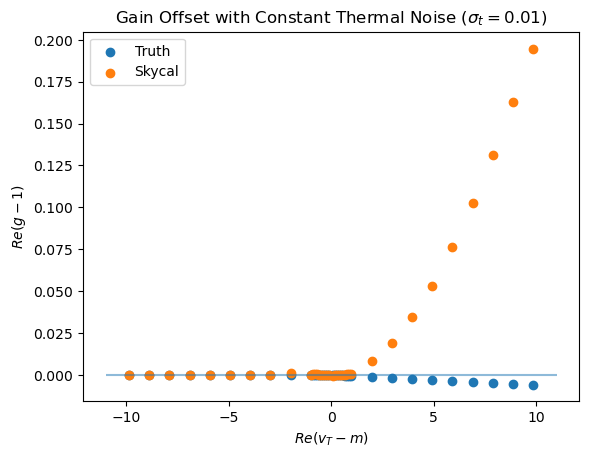

In [4]:
plt.scatter(vT_minus_m_gaussian_very_small_noise, real_g_minus_1_truth_gaussian_very_small_noise, label="Truth")
plt.scatter(vT_minus_m_gaussian_very_small_noise, real_g_minus_1_skycal_gaussian_very_small_noise, label="Skycal")
plt.legend()
plt.ylabel("$Re(g-1)$")
plt.xlabel("$Re(v_T - m)$")
plt.title("Gain Offset with Constant Thermal Noise ($\\sigma_t = 0.01$)") 
plt.hlines(xmin=-11,xmax=11,y=0,alpha=0.5) 

In [5]:
size = len(vT_minus_m_over_sigma_t_gaussian)
rgb_list = mpl.cm.rainbow(np.linspace(0, 1, size // 2))

# vT_minus_m_over_sigma_t_combo = np.concat(
#     vT_minus_m_over_sigma_t_gaussian, vT_minus_m_over_sigma_t_fhd
# )
# real_g_minus_1_truth_combo = np.cocat(
#     real_g_minus_1_truth_gaussian, real_g_minus_1_truth_fhd
# )
# real_g_minus_1_skycal_combo = np.concat(
#     real_g_minus_1_skycal_gaussian,real_g_minus_1_skycal_fhd
# )

fig, ax = plt.subplots()
# for val in range(size):
#     ax.annotate(
#         "",
#         xytext=(
#             real_g_minus_1_skycal_gaussian[val],
#             vT_minus_m_over_sigma_t_gaussian[val],
#         ),
#         xy=(
#             real_g_minus_1_truth_gaussian[val],
#             vT_minus_m_over_sigma_t_gaussian[val],
#         ),
#         arrowprops=dict(arrowstyle="->"),
#     )
ax.scatter(real_g_minus_1_truth_gaussian[:size//2], vT_minus_m_gaussian[:size//2], c=rgb_list)
ax.scatter(real_g_minus_1_truth_gaussian[size//2:], vT_minus_m_gaussian[size//2:], 
            edgecolors=rgb_list, facecolors='none')
ax.set_title("$Log[Re(g-1)]$ vs $Log[Re(v_T - m)]$\n(Gaussian - Truth)")
ax.set_ylabel("$Log[Re(v_T - m)]$")
ax.set_xlabel("$Log[Re(g-1)]$")
x_min=np.min(np.min([real_g_minus_1_truth_gaussian, real_g_minus_1_skycal_gaussian]))
x_max=np.max(np.max([real_g_minus_1_truth_gaussian, real_g_minus_1_skycal_gaussian]))
y_min=np.min(vT_minus_m_over_sigma_t_gaussian)
y_max=np.max(vT_minus_m_over_sigma_t_gaussian)
ax.set_ylim(-15,15)
ax.set_xlim(-0.02,0.5)
ax.set_xscale("symlog")
ax.set_yscale("symlog")
ax.hlines(0,x_min,x_max,colors='black',linestyles='dashed',lw=1)
ax.vlines(0,y_min,y_max,colors='black',linestyles='dashed',lw=1)
plt.savefig('images/gain_error_vs_model_error_'
            + subprocess.check_output(['git','rev-parse','--short','HEAD']).decode('ascii').strip()
            + '_gaussian' + '.png',
            bbox_inches=0,)
plt.close()

fig, ax = plt.subplots()
ax.scatter(real_g_minus_1_truth_gaussian[:size//2], sigma_t_gaussian[:size//2], c=rgb_list)
ax.scatter(real_g_minus_1_truth_gaussian[size//2:], sigma_t_gaussian[size//2:],
            edgecolors=rgb_list, facecolors='none')
ax.set_title("$Log[Re(g-1)]$ vs $Log [\\sigma_t]$\n(Gaussian - Truth)")
ax.set_ylabel("$Log [\\sigma_t]$")
ax.set_xlabel("$Log[Re(g-1)]$")
ax.set_ylim(-0.1,15)
ax.set_xlim(-0.02,0.5)
ax.set_xscale("symlog")
ax.set_yscale("symlog")
ax.hlines(0,-0.1,0.5,colors='black',linestyles='dashed',lw=1)
ax.vlines(0,-15,15,colors='black',linestyles='dashed',lw=1)
plt.savefig('images/gain_error_vs_thermal_noise_'
            + subprocess.check_output(['git','rev-parse','--short','HEAD']).decode('ascii').strip()
            + '_gaussian' + '.png',
            bbox_inches=0,)
plt.close()

fig, ax = plt.subplots()
ax.scatter(real_g_minus_1_truth_gaussian[:size//2], vT_minus_m_over_sigma_t_gaussian[:size//2], c=rgb_list)
ax.scatter(real_g_minus_1_truth_gaussian[size//2:], vT_minus_m_over_sigma_t_gaussian[size//2:],
            edgecolors=rgb_list, facecolors='none')
ax.set_title("$Log[Re(g-1)]$ vs $Log[Re(v_T - m)/\\sigma_t]$\n(Gaussian - Truth)")
ax.set_ylabel("$Log[(Re(v_T - m)/\\sigma_t)]$")
ax.set_xlabel("$Log[Re(g-1)]$")
ax.set_ylim(-15,15)
ax.set_xlim(-0.02,0.5)
ax.set_xscale("symlog")
ax.set_yscale("symlog")
ax.hlines(0,-0.5,0.5,colors='black',linestyles='dashed',lw=1)
ax.vlines(0,-15,15,colors='black',linestyles='dashed',lw=1)
plt.savefig('images/gain_error_vs_model_error_thermal_noise_'
            + subprocess.check_output(['git','rev-parse','--short','HEAD']).decode('ascii').strip()
            + '_gaussian' + '.png',
            bbox_inches=0,)
plt.close()

"""
    Skycal plots
"""

fig, ax = plt.subplots()
ax.scatter(real_g_minus_1_skycal_gaussian[:size//2], vT_minus_m_gaussian[:size//2], c=rgb_list)
ax.scatter(real_g_minus_1_skycal_gaussian[size//2:], vT_minus_m_gaussian[size//2:], 
            edgecolors=rgb_list, facecolors='none')
ax.set_title("$Log[Re(g-1)]$ vs $Log[Re(v_T - m)]$\n(Gaussian - Skycal)")
ax.set_ylabel("$Log[Re(v_T - m)]$")
ax.set_xlabel("$Log[Re(g-1)]$")
# x_min=np.min(np.min([real_g_minus_1_skycal_gaussian, real_g_minus_1_skycal_gaussian]))
# x_max=np.max(np.max([real_g_minus_1_skycal_gaussian, real_g_minus_1_skycal_gaussian]))
# y_min=np.min(vT_minus_m_over_sigma_t_gaussian)
# y_max=np.max(vT_minus_m_over_sigma_t_gaussian)
ax.set_ylim(-15,15)
ax.set_xlim(-0.15,0.15)
ax.set_xscale("symlog")
ax.set_yscale("symlog")
ax.hlines(0,-0.15,0.15,colors='black',linestyles='dashed',lw=1)
ax.vlines(0,-15,15,colors='black',linestyles='dashed',lw=1)
plt.savefig('images/gain_error_vs_model_error_'
            + subprocess.check_output(['git','rev-parse','--short','HEAD']).decode('ascii').strip()
            + '_skycal' + '.png',
            bbox_inches=0,)
plt.close()

fig, ax = plt.subplots()
ax.scatter(real_g_minus_1_skycal_gaussian[:size//2], sigma_t_gaussian[:size//2], c=rgb_list)
ax.scatter(real_g_minus_1_skycal_gaussian[size//2:], sigma_t_gaussian[size//2:],
            edgecolors=rgb_list, facecolors='none')
ax.set_title("$Log[Re(g-1)]$ vs $Log [\\sigma_t]$\n(Gaussian - Skycal)")
ax.set_ylabel("$Log [\\sigma_t]$")
ax.set_xlabel("$Log[Re(g-1)]$")
ax.set_ylim(-0.1,15)
ax.set_xlim(-0.15,0.15)
ax.set_xscale("symlog")
ax.set_yscale("symlog")
ax.hlines(0,-0.15,0.15,colors='black',linestyles='dashed',lw=1)
ax.vlines(0,-15,15,colors='black',linestyles='dashed',lw=1)
plt.savefig('images/gain_error_vs_thermal_noise_'
            + subprocess.check_output(['git','rev-parse','--short','HEAD']).decode('ascii').strip()
            + '_skycal' + '.png',
            bbox_inches=0,)
plt.close()

fig, ax = plt.subplots()
ax.scatter(real_g_minus_1_skycal_gaussian[:size//2], vT_minus_m_over_sigma_t_gaussian[:size//2], c=rgb_list)
ax.scatter(real_g_minus_1_skycal_gaussian[size//2:], vT_minus_m_over_sigma_t_gaussian[size//2:],
            edgecolors=rgb_list, facecolors='none')
ax.set_title("$Log[Re(g-1)]$ vs $Log[Re(v_T - m)/\\sigma_t]$\n(Gaussian - Skycal)")
ax.set_ylabel("$Log[(Re(v_T - m)/\\sigma_t)]$")
ax.set_xlabel("$Log[Re(g-1)]$")
ax.set_ylim(-15,15)
ax.set_xlim(-0.15,0.15)
ax.set_xscale("symlog")
ax.set_yscale("symlog")
ax.hlines(0,-0.15,0.15,colors='black',linestyles='dashed',lw=1)
ax.vlines(0,-15,15,colors='black',linestyles='dashed',lw=1)
plt.savefig('images/gain_error_vs_model_error_thermal_noise_'
            + subprocess.check_output(['git','rev-parse','--short','HEAD']).decode('ascii').strip()
            + '_skycal' + '.png',
            bbox_inches=0,)
plt.close()

"""
    Trajectory plots
"""

fig, ax = plt.subplots()
for val in range(size):
    ax.annotate(
        "",
        xytext=(
            real_g_minus_1_truth_gaussian[val],
            vT_minus_m_gaussian[val],
        ),
        xy=(
            real_g_minus_1_skycal_gaussian[val],
            vT_minus_m_gaussian[val],
        ),
        arrowprops=dict(arrowstyle="->"),
    )
ax.set_title("$Log[Re(v_T - m)]$ Gain Error - Truth $\\to$ Skycal\n(Gaussian simulation)")
ax.set_ylabel("$Log[Re(v_T - m)]$")
ax.set_xlabel("$Re(g-1)$")
ax.set_ylim(-15,15)
ax.set_xlim(-0.5,0.5)
ax.set_yscale("symlog")
ax.hlines(0,-0.5,0.5,colors='black',linestyles='dashed',lw=1)
ax.vlines(0,-15,15,colors='black',linestyles='dashed',lw=1)
plt.savefig('images/gain_error_vs_model_error_'
            + subprocess.check_output(['git','rev-parse','--short','HEAD']).decode('ascii').strip()
            + '_trajectory' + '.png',
            bbox_inches=0,)
plt.close()

fig, ax = plt.subplots()
for val in range(size):
    ax.annotate(
        "",
        xytext=(
            real_g_minus_1_truth_gaussian[val],
            sigma_t_gaussian[val],
        ),
        xy=(
            real_g_minus_1_skycal_gaussian[val],
            sigma_t_gaussian[val],
        ),
        arrowprops=dict(arrowstyle="->"),
    )
ax.set_title("$Log[\\sigma_t]$ Gain Error - Truth $\\to$ Skycal\n(Gaussian simulation)")
ax.set_ylabel("$Log[\\sigma_t$]")
ax.set_xlabel("$Re(g-1)$")
ax.set_ylim(-0.1,15)
ax.set_xlim(-0.5,0.5)
ax.set_yscale("symlog")
ax.hlines(0,-0.5,0.5,colors='black',linestyles='dashed',lw=1)
ax.vlines(0,-0.1,15,colors='black',linestyles='dashed',lw=1)
plt.savefig('images/gain_error_vs_thermal_noise_'
            + subprocess.check_output(['git','rev-parse','--short','HEAD']).decode('ascii').strip()
            + '_trajectory' + '.png',
            bbox_inches=0,)
plt.close()

fig, ax = plt.subplots()
for val in range(size):
    ax.annotate(
        "",
        xytext=(
            real_g_minus_1_truth_gaussian[val],
            vT_minus_m_over_sigma_t_gaussian[val],
        ),
        xy=(
            real_g_minus_1_skycal_gaussian[val],
            vT_minus_m_over_sigma_t_gaussian[val],
        ),
        arrowprops=dict(arrowstyle="->"),
    )
ax.set_title("$Log[Re(v_T - m) / \\sigma_t]$ Gain Error - Truth $\\to$ Skycal\n(Gaussian simulation)")
ax.set_ylabel("$Log[Re(v_T - m) / \\sigma_t]$")
ax.set_xlabel("$Re(g-1)$")
ax.set_ylim(-15,15)
ax.set_xlim(-0.5,0.5)
ax.set_yscale("symlog")
ax.hlines(0,-0.5,0.5,colors='black',linestyles='dashed',lw=1)
ax.vlines(0,-15,15,colors='black',linestyles='dashed',lw=1)
plt.savefig('images/gain_error_vs_model_error_thermal_noise_'
            + subprocess.check_output(['git','rev-parse','--short','HEAD']).decode('ascii').strip()
            + '_trajectory' + '.png',
            bbox_inches=0,)
plt.close()

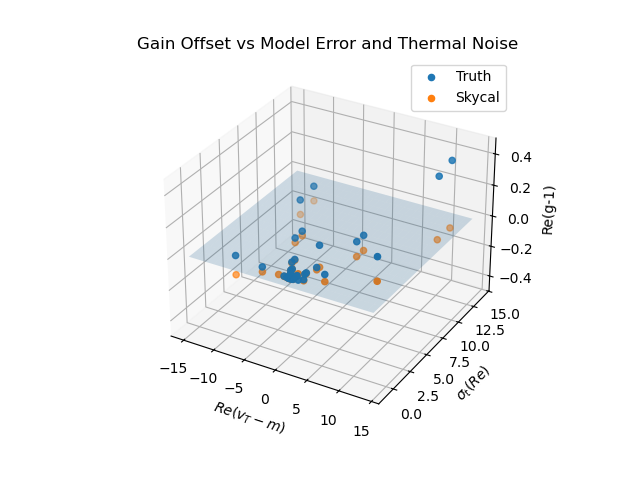

In [6]:
%matplotlib widget

fig = plt.figure()
ax = fig.add_subplot(projection='3d')

ax.scatter(vT_minus_m_gaussian, sigma_t_gaussian, real_g_minus_1_truth_gaussian, label="Truth")
ax.scatter(vT_minus_m_gaussian, sigma_t_gaussian, real_g_minus_1_skycal_gaussian, label="Skycal")
xx, yy = np.meshgrid(range(-15,15), range(-1,15))
zz = 0 * np.ones_like(xx)
ax.plot_surface(xx,yy,zz, alpha=0.2)
ax.set_title("Gain Offset vs Model Error and Thermal Noise")
ax.set_xlabel("$Re(v_T - m)$")
ax.set_ylabel("$\\sigma_t (Re)$")
ax.set_zlabel("Re(g-1)")
ax.set_zlim(-0.5, 0.5)
# ax.set_xscale("symlog")
# ax.set_yscale("symlog")
# ax.set_zscale("symlog")
plt.legend()

plt.show()

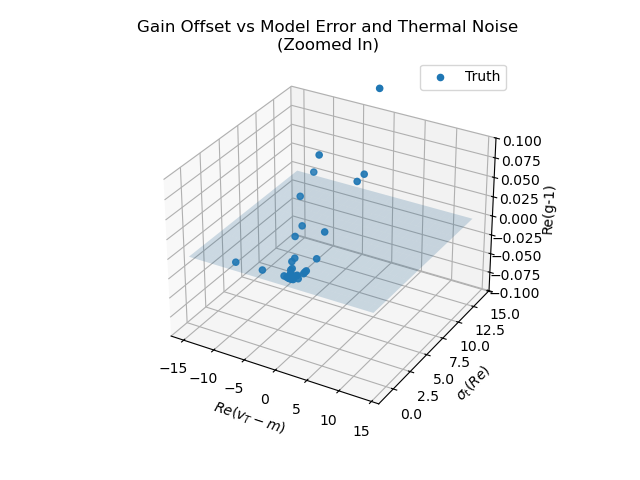

In [7]:
%matplotlib widget

fig = plt.figure()
ax = fig.add_subplot(projection='3d')

ax.scatter(vT_minus_m_gaussian, sigma_t_gaussian, real_g_minus_1_truth_gaussian, label="Truth")
# ax.scatter(vT_minus_m_gaussian, sigma_t_gaussian, real_g_minus_1_skycal_gaussian, label="Skycal", c="orange")
xx, yy = np.meshgrid(range(-15,15), range(-1,15))
zz = 0 * np.ones_like(xx)
ax.plot_surface(xx,yy,zz, alpha=0.2)
ax.set_title("Gain Offset vs Model Error and Thermal Noise\n(Zoomed In)")
ax.set_xlabel("$Re(v_T - m)$")
ax.set_ylabel("$\\sigma_t (Re)$")
ax.set_zlabel("Re(g-1)")
ax.set_zlim(-0.1, 0.1)
# ax.set_xscale("symlog")
# ax.set_yscale("symlog")
# ax.set_zscale("symlog")
plt.legend()

plt.show()

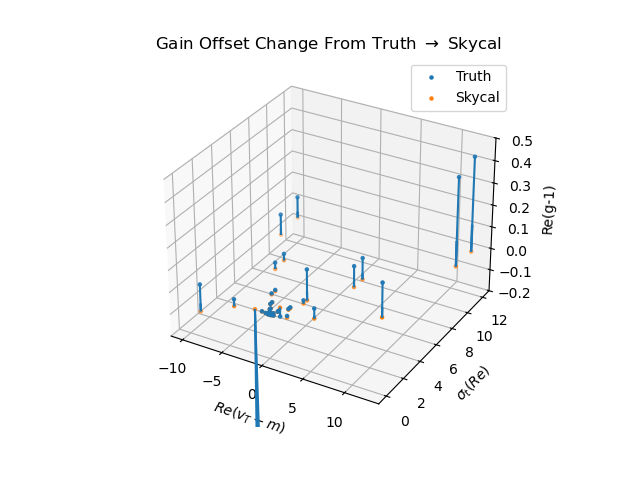

In [8]:
%matplotlib widget

fig = plt.figure()
ax = fig.add_subplot(projection='3d')

xx = vT_minus_m_gaussian
yy = sigma_t_gaussian
zz = real_g_minus_1_truth_gaussian
uu = vT_minus_m_gaussian - xx
vv = sigma_t_gaussian - yy
ww = real_g_minus_1_skycal_gaussian - zz
ax.quiver(xx, yy, zz, uu, vv, ww)
ax.scatter(vT_minus_m_gaussian, sigma_t_gaussian, real_g_minus_1_truth_gaussian, s=5, label="Truth")
ax.scatter(vT_minus_m_gaussian, sigma_t_gaussian, real_g_minus_1_skycal_gaussian, s=5, label="Skycal")
ax.set_title("Gain Offset Change From Truth $\\to$ Skycal")
ax.set_xlabel("$Re(v_T - m)$")
ax.set_ylabel("$\\sigma_t (Re)$")
ax.set_zlabel("Re(g-1)")
ax.set_zlim(-0.2, 0.5)
# ax.set_xscale("symlog")
# ax.set_yscale("symlog")
# ax.set_zscale("symlog")
plt.legend()

plt.show()

In [10]:
import pickle
import gain_error_offset_analysis as geoa

# with open(f'calico/data/gain_error_offset_analysis_vT_minus_m.pkl', 'rb') as file:
#     vT_minus_m_gaussian = pickle.load(file)
# with open(f'calico/data/gain_error_offset_analysis_real_sigma_t_calculated_gaussian.pkl', 'rb') as file:
#     sigma_t_gaussian = pickle.load(file)
# with open(f'calico/data/gain_error_offset_analysis_real_g_minus_1_truth_gaussian', 'rb') as file:
#     real_g_minus_1_truth_gaussian = pickle.load(file)
# with open(f'calico/data/gain_error_offset_analysis_real_g_minus_1_skycal_gaussian', 'rb') as file:
#     real_g_minus_1_skycal_gaussian = pickle.load(file)

vT_minus_m_gaussian, sigma_t_gaussian, real_g_minus_1_truth_gaussian, real_g_minus_1_skycal_gaussian = geoa.main()

%matplotlib widget

fig = plt.figure()
ax = fig.add_subplot(projection='3d')

ax.scatter(vT_minus_m_gaussian, sigma_t_gaussian, real_g_minus_1_truth_gaussian, label="Truth")
ax.scatter(vT_minus_m_gaussian, sigma_t_gaussian, real_g_minus_1_skycal_gaussian, label="Skycal")
xx, yy = np.meshgrid(range(np.min(vT_minus_m_gaussian) - 1, np.max(vT_minus_m_gaussian) + 1), 
                     range(np.min(sigma_t_gaussian) - 1, np.max(sigma_t_gaussian) + 1))
zz = 0 * np.ones_like(xx)
ax.plot_surface(xx,yy,zz, alpha=0.2)
ax.set_title("Gain Offset vs Model Error and Thermal Noise")
ax.set_xlabel("$Re(v_T - m)$")
ax.set_ylabel("$\\sigma_t (Re)$")
ax.set_zlabel("Re(g-1)")
ax.set_zlim(np.min([np.min(real_g_minus_1_truth_gaussian) - 1, np.min(real_g_minus_1_skycal_gaussian)] + 1), 
            np.max([np.max(real_g_minus_1_truth_gaussian) - 1, np.max(real_g_minus_1_skycal_gaussian)] + 1))
# ax.set_xscale("symlog")
# ax.set_yscale("symlog")
# ax.set_zscale("symlog")
plt.legend()

plt.show()

FileNotFoundError: [Errno 2] No such file or directory: 'calico/data/original_many_realizations.pkl'